In [227]:
import folium
import pandas as pd 
from scrapper.AlquilerScrapper import Scrapper
import numpy as np
import matplotlib.pyplot as plt
from skgstat import Variogram
import geopandas as gpd
from shapely.geometry import Point
import statsmodels.api as sm
import ast

Lectura y limpieza de datos

1. se leen los datos y se transforman en geodataframe añadiendo finromación sobre el barrio en CABA
2. Se borran los datos pertenecientes a barrios con menos de 5 datos
3. Se añade información sobre la cantidad de ambientes, pasando strings a nueros
4. Se añade la columna de area por metro cuadrado "area_m2", transformando los datos de string a numericos. Se borran los datos sin información de area x metro cuadradp
5. Se añade la columna expensas transformando string a numerico. Si no hay información de expensas, se asume que el valor es 0.
6. Se borran los datos con precio de alquiler menor a 100000 pesos

In [228]:
df = pd.read_csv("storage/data/historic/arg_venta_data.csv")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4968 entries, 0 to 4967
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                4968 non-null   int64  
 1   url               4968 non-null   object 
 2   precio            4968 non-null   object 
 3   expensas          4968 non-null   float64
 4   area_m2           4839 non-null   float64
 5   dormitorios       3706 non-null   object 
 6   antiguedad        3597 non-null   float64
 7   tipo_inmueble     4968 non-null   object 
 8   puntaje_arg_prop  4968 non-null   int64  
 9   imagen_path       4958 non-null   object 
 10  image_url         4968 non-null   object 
 11  lat               4837 non-null   float64
 12  lon               4837 non-null   float64
 13  valido_desde      4968 non-null   object 
 14  valido_hasta      181 non-null    object 
dtypes: float64(5), int64(2), object(8)
memory usage: 582.3+ KB


Feature engeneering

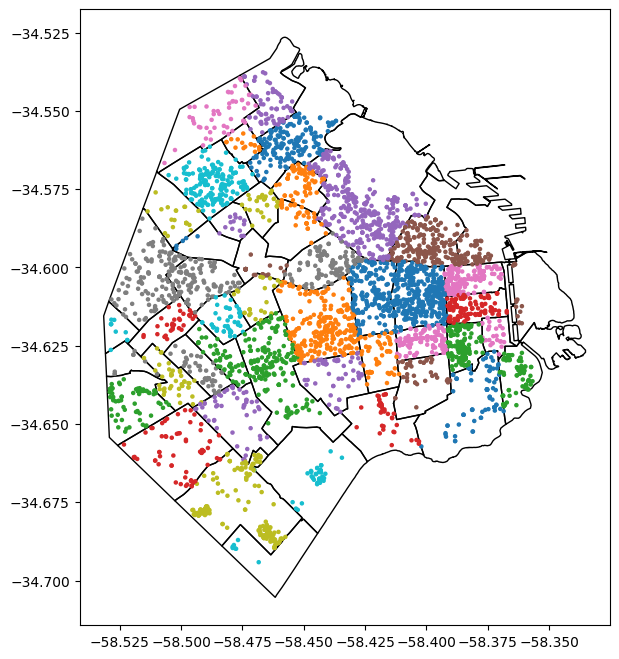

In [229]:


# Barrios
barrios = gpd.read_file("barrios.geojson")

# Puntos
gdf_puntos = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
)

# Unificar CRS
barrios = barrios.to_crs(gdf_puntos.crs)
gdf_join = gpd.sjoin(
    gdf_puntos,
    barrios,
    how="left",
    predicate="within"
)


gdf_deptos = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
)

gdf_join = gpd.sjoin(
    gdf_deptos,
    barrios[['nombre', 'comuna', 'geometry']],
    how='left',
    predicate='within'
)
gdf_join = gdf_join.rename(columns={"nombre": "barrio"})

fig, ax = plt.subplots(figsize=(8, 8))
barrios.plot(ax=ax, edgecolor="black", facecolor="none")

gdf_join.plot(
    ax=ax,
    column='barrio',
    markersize=5,
    legend=False
)

# Eliminamos barrios con menos de 5 observaciones
gdf_join = gdf_join[
    gdf_join.groupby('barrio')['barrio'].transform('size') >= 5
]


In [230]:
gdf_join['precio']

0         ('usd', 69500.0)
1        ('usd', 320000.0)
2         ('usd', 84900.0)
3        ('usd', 120000.0)
4         ('usd', 58000.0)
               ...        
4963     ('usd', 750000.0)
4964      ('usd', 65000.0)
4965     ('usd', 155800.0)
4966     ('usd', 179900.0)
4967    ('usd', 2350000.0)
Name: precio, Length: 4797, dtype: object

In [231]:
gdf_join['dormitorios'] = gdf_join['dormitorios'].fillna(0)
gdf_join['ambientes'] = gdf_join['dormitorios'].astype(str).str.extract('(\d+)').astype(int) + 1
gdf_join['ambientes']

print("cantidad de nulos en area_m2:", gdf_join['area_m2'].isna().sum())


mask = gdf_join['area_m2'].isna() & gdf_join['ambientes'].notna()

gdf_join.loc[mask, 'area_m2'] = (
    gdf_join.groupby('ambientes')['area_m2']
      .transform('median')
      .loc[mask]
)


gdf_join['expensas'] = pd.to_numeric(gdf_join['expensas'], errors='coerce')

print("cantidad de nulos en expensas:", gdf_join['expensas'].isna().sum())

gdf_join['expensas'].fillna(0, inplace=True)


gdf_join = gdf_join[~gdf_join['precio'].apply(lambda x: pd.isna(x[0]))]
valor_dolar_oficial_venta = pd.read_csv("storage/data/dolar_hoy.csv").iloc[0]['valor']



def parse_precio(x):
    if pd.isna(x):
        return (None, None)
    if isinstance(x, tuple):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return (None, None)
    return (None, None)


parsed = gdf_join['precio'].apply(parse_precio)

gdf_join['moneda'] = parsed.str[0]
gdf_join['precio'] = pd.to_numeric(parsed.str[1], errors='coerce')

gdf_join = gdf_join[~gdf_join['precio'].isna()]


gdf_join = pd.get_dummies(
    gdf_join,
    columns=['tipo_inmueble'],
    drop_first=True  
).reset_index(drop=True)

gdf_join.head()


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
cantidad de nulos en area_m2: 121
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
cantidad de nulos en expensas: 0
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alway

,id,url,precio,expensas,area_m2,dormitorios,antiguedad,puntaje_arg_prop,imagen_path,image_url,...,valido_desde,valido_hasta,geometry,index_right,barrio,comuna,ambientes,moneda,tipo_inmueble_departamento,tipo_inmueble_ph
0,8369836,https://www.argenprop.com/departamento-en-vent...,69500.000000000,105000.000000000,45.000000000,0,NaN,1,images/8369836.jpg,https://www.argenprop.com/static-content/63896...,...,2026-01-17 17:05:21.567385,NaN,POINT (-58.45169 -34.60627),7.000000000,Caballito,6.000000000,1,usd,True,False
1,18875283,https://www.argenprop.com/departamento-en-vent...,320000.000000000,0.000000000,69.000000000,2 dorm.,16.000000000,0,images/18875283.jpg,https://proxy.sosiva451.com/proxy/0996ADC553ED...,...,2026-01-17 17:05:21.583377,NaN,POINT (-58.43031 -34.5767),20.000000000,Palermo,14.000000000,3,usd,True,False
2,15860074,https://www.argenprop.com/departamento-en-vent...,84900.000000000,110000.000000000,63.000000000,2 dorm.,NaN,1,images/15860074.jpg,https://www.argenprop.com/static-content/47006...,...,2026-01-17 17:05:21.597368,NaN,POINT (-58.46879 -34.63223),12.000000000,Flores,7.000000000,3,usd,True,False
3,18342065,https://www.argenprop.com/departamento-en-vent...,120000.000000000,258000.000000000,45.000000000,2 dorm.,NaN,1,images/18342065.jpg,https://www.argenprop.com/static-content/56024...,...,2026-01-17 17:05:21.605364,NaN,POINT (-58.49293 -34.62398),13.000000000,Floresta,10.000000000,3,usd,True,False
4,18770885,https://www.argenprop.com/departamento-en-vent...,58000.000000000,142000.000000000,36.000000000,1 dorm.,NaN,1,images/18770885.jpg,https://www.argenprop.com/static-content/58807...,...,2026-01-17 17:05:21.615360,NaN,POINT (-58.47018 -34.62986),12.000000000,Flores,7.000000000,2,usd,True,False


Elimino los precios muy bajos (menores a 8000 USD) y añado una columna con el precio por metro cuadrado

In [232]:
gdf_join = gdf_join.drop(gdf_join[gdf_join['precio'] <= 8000]['precio'].index)

EDA

Hipotesis: El precio depende de la superficie (en m^2) y de la cantidad de ambientes, pero esta relación es igual en todo el mapa?
Por ejemplo, podría ser que si comparamos un departamento con x m^2 y 3 ambientes y vemos cuanto cambia el precio al añadir 1 ambiente más, la diferencia d eprecio sea mayor en palermo que en caballito, por lo que existe una dependencia espacial en la relación subyacente (quizá en palermo no es tan importante tener muchos ambientes y en caballito si) 

Analisis: Graficar la dependencia entre precio en USD y superficie en m^2 para cada cantidad de ambientes en cada barrio
Si vemos que las pendientes de las curvas para cada cantidad de ambientes cambia en los distintos barrios, estamos evidenciando una dependencia espacial en la relación.


In [233]:
densidad_naive = (
    gdf_join
    .groupby('barrio')
    .size()
    .sort_values(ascending=False)
)

densidad_naive.head()


barrio
Balvanera        420
Palermo          410
Caballito        301
Constitucion     224
Villa Urquiza    211
dtype: int64

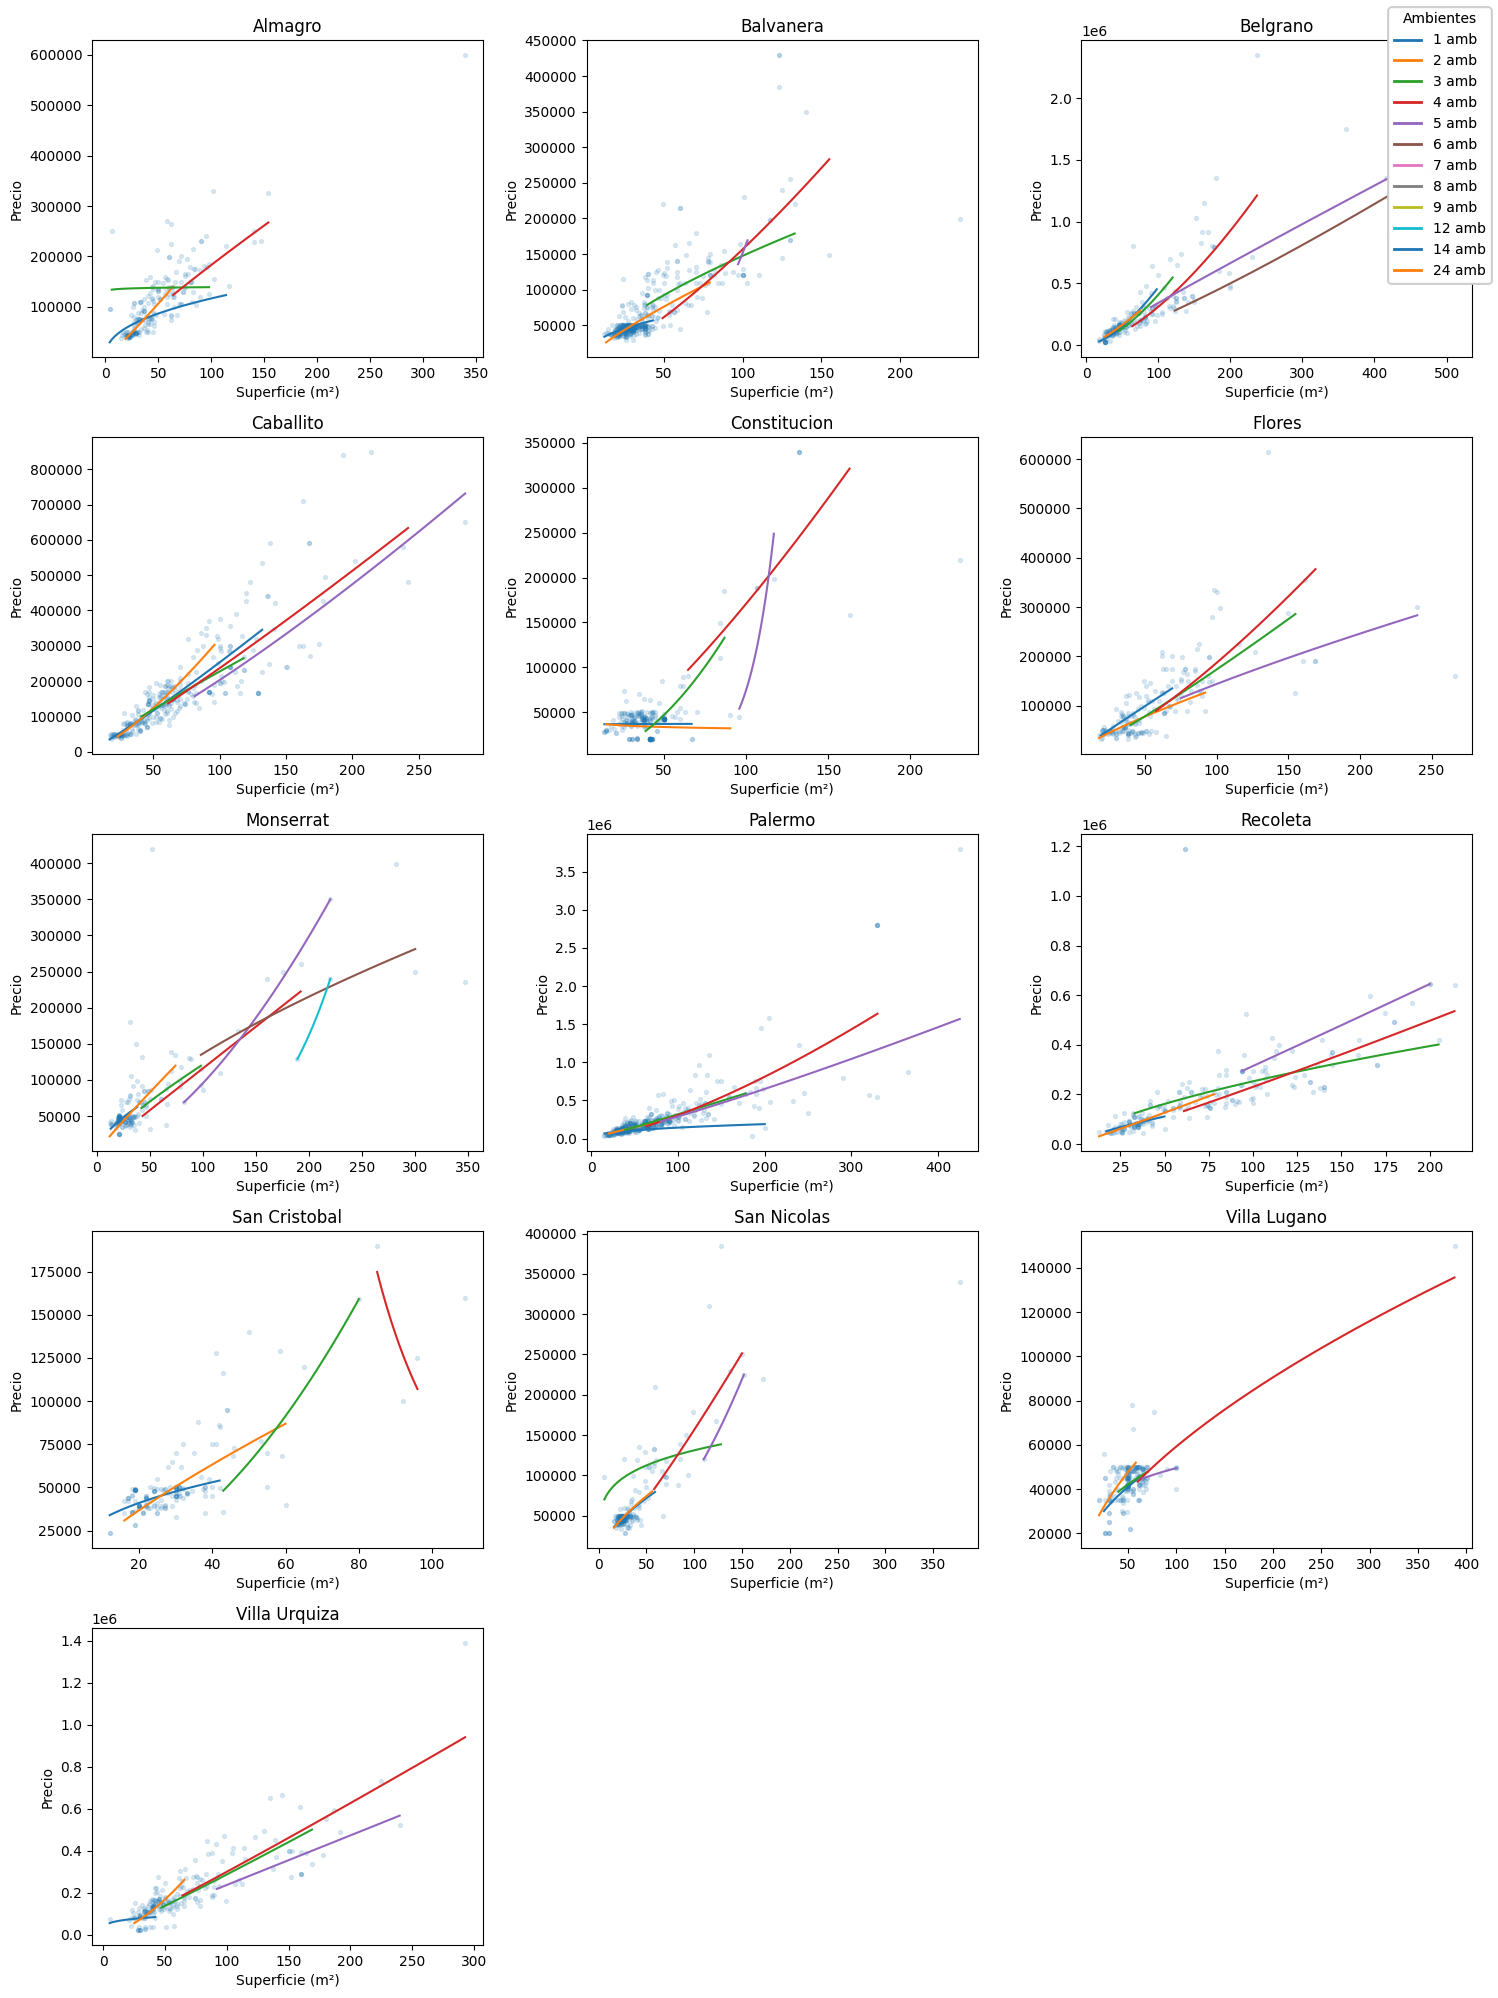

In [234]:
################## cambiar min obs ##################
min_obs = 150

barrios_con_observaciones = (
    gdf_join
    .groupby('barrio')
    .size()
    .loc[lambda s: s >= min_obs]
    .index
    .tolist()
)

n = len(barrios_con_observaciones)
ncols = 3
nrows = int(np.ceil(n / ncols))

import matplotlib.cm as cm
from matplotlib.lines import Line2D

ambientes = sorted(gdf_join['ambientes'].unique())
cmap = cm.get_cmap("tab10")

color_por_amb = {
    amb: cmap(i % cmap.N)
    for i, amb in enumerate(ambientes)
}

# Límites globales
xmin = gdf_join['area_m2'].min()
xmax = 400

ymin = gdf_join['precio'].min()
ymax = 2*1e6


fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for ax, barrio in zip(axes, barrios_con_observaciones):

    gdf_b = gdf_join[gdf_join['barrio'] == barrio]

    # ---- densidad de puntos ----
    ax.scatter(
        gdf_b['area_m2'],
        gdf_b['precio'],
        s=8,
        alpha=0.15
    )

    for amb in sorted(gdf_b['ambientes'].unique()):
        sub = gdf_b[gdf_b['ambientes'] == amb]

        X = sm.add_constant(np.log(sub['area_m2']))
        y = np.log(sub['precio'])

        model = sm.OLS(y, X).fit()

        x_grid = np.linspace(
            sub['area_m2'].min(),
            sub['area_m2'].max(),
            100
        )

        y_hat = model.predict(
            sm.add_constant(np.log(x_grid))
        )

        ax.plot(
            x_grid,
            np.exp(y_hat),
            color=color_por_amb[amb],
            label=f'{amb} amb'
        )



    ax.set_title(barrio)
    ax.set_xlabel('Superficie (m²)')
    ax.set_ylabel('Precio')

    legend_elements = [
        Line2D(
            [0], [0],
            color=color_por_amb[amb],
            lw=2,
            label=f'{amb} amb'
        )
        for amb in ambientes
    ]

    fig.legend(
        handles=legend_elements,
        loc='upper right',
        title='Ambientes'
    )

for ax in axes[len(barrios_con_observaciones):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


# analisis de antiguedad


In [235]:
gdf_join[gdf_join['antiguedad'].isna()]

,id,url,precio,expensas,area_m2,dormitorios,antiguedad,puntaje_arg_prop,imagen_path,image_url,...,valido_desde,valido_hasta,geometry,index_right,barrio,comuna,ambientes,moneda,tipo_inmueble_departamento,tipo_inmueble_ph
0,8369836,https://www.argenprop.com/departamento-en-vent...,69500.000000000,105000.000000000,45.000000000,0,NaN,1,images/8369836.jpg,https://www.argenprop.com/static-content/63896...,...,2026-01-17 17:05:21.567385,NaN,POINT (-58.45169 -34.60627),7.000000000,Caballito,6.000000000,1,usd,True,False
2,15860074,https://www.argenprop.com/departamento-en-vent...,84900.000000000,110000.000000000,63.000000000,2 dorm.,NaN,1,images/15860074.jpg,https://www.argenprop.com/static-content/47006...,...,2026-01-17 17:05:21.597368,NaN,POINT (-58.46879 -34.63223),12.000000000,Flores,7.000000000,3,usd,True,False
3,18342065,https://www.argenprop.com/departamento-en-vent...,120000.000000000,258000.000000000,45.000000000,2 dorm.,NaN,1,images/18342065.jpg,https://www.argenprop.com/static-content/56024...,...,2026-01-17 17:05:21.605364,NaN,POINT (-58.49293 -34.62398),13.000000000,Floresta,10.000000000,3,usd,True,False
4,18770885,https://www.argenprop.com/departamento-en-vent...,58000.000000000,142000.000000000,36.000000000,1 dorm.,NaN,1,images/18770885.jpg,https://www.argenprop.com/static-content/58807...,...,2026-01-17 17:05:21.615360,NaN,POINT (-58.47018 -34.62986),12.000000000,Flores,7.000000000,2,usd,True,False
13,18875425,https://www.argenprop.com/departamento-en-vent...,84900.000000000,51000.000000000,32.000000000,1 dorm.,NaN,0,images/18875425.jpg,https://www.argenprop.com/static-content/52457...,...,2026-01-17 17:05:21.694312,NaN,POINT (-58.50473 -34.60246),36.000000000,Villa Del Parque,11.000000000,2,usd,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4759,16143794,https://www.argenprop.com/departamento-en-vent...,88500.000000000,220000.000000000,83.000000000,2 dorm.,NaN,45,images/16143794.jpg,https://proxy.sosiva451.com/proxy/74B4AD2C1116...,...,2026-01-26 01:00:27.068900,NaN,POINT (-58.3854 -34.6013),31.000000000,San Nicolas,1.000000000,3,usd,True,False
4760,18277183,https://www.argenprop.com/departamento-en-vent...,1579700.000000000,0.000000000,205.000000000,3 dorm.,NaN,1,images/18277183.jpg,https://proxy.sosiva451.com/proxy/354A4D2CCCA0...,...,2026-01-26 01:00:27.116618,NaN,POINT (-58.41367 -34.57971),20.000000000,Palermo,14.000000000,4,usd,True,False
4761,16984458,https://www.argenprop.com/departamento-en-vent...,222148.000000000,0.000000000,42.000000000,1 dorm.,NaN,2,images/16984458.jpg,https://proxy.sosiva451.com/proxy/CED0691F2E81...,...,2026-01-26 01:00:27.179974,NaN,POINT (-58.47476 -34.57419),47.000000000,Villa Urquiza,12.000000000,2,usd,True,False
4762,17312338,https://www.argenprop.com/departamento-en-vent...,116250.000000000,0.000000000,32.000000000,0,NaN,2,images/17312338.jpg,https://proxy.sosiva451.com/proxy/EA164616D077...,...,2026-01-26 01:00:27.246588,NaN,POINT (-58.40366 -34.58759),27.000000000,Recoleta,2.000000000,1,usd,True,False


Extraigo datos antiguedad, relleno con la media del barrio cuando no esta precenta (a muchos a estrenar le estoy poniendo mal el dato, se tiene que corregir.)

In [236]:

gdf_join['antiguedad'] = (
    gdf_join['antiguedad']
    .fillna(
        gdf_join
        .groupby('barrio')['antiguedad']
        .transform('mean')
    )
)

gdf_join[gdf_join['antiguedad'].isna()]

,id,url,precio,expensas,area_m2,dormitorios,antiguedad,puntaje_arg_prop,imagen_path,image_url,...,valido_desde,valido_hasta,geometry,index_right,barrio,comuna,ambientes,moneda,tipo_inmueble_departamento,tipo_inmueble_ph


Variograma por precio

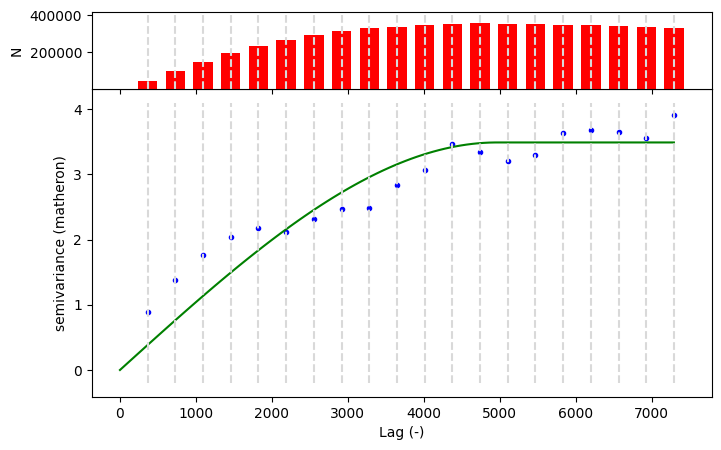

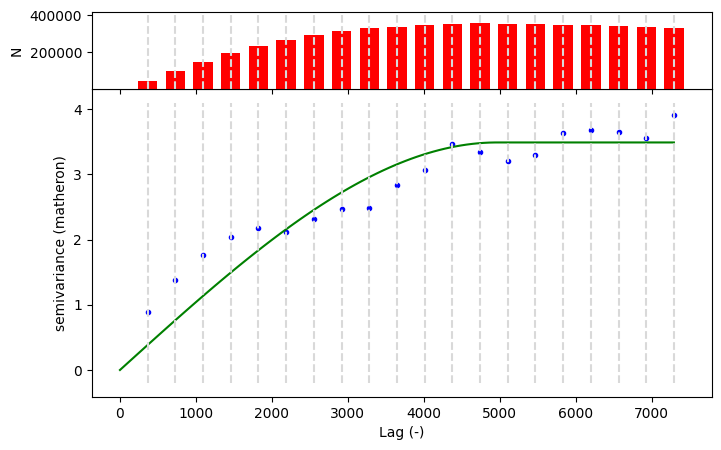

In [237]:


gdf = gdf_join.to_crs(epsg=3857)
coords = np.column_stack([
    gdf.geometry.x,
    gdf.geometry.y
])

values = gdf['precio'].values

V = Variogram(
    coords,
    values,
    model='spherical',   # o 'exponential', 'gaussian'
    n_lags=20,
    maxlag='median',     # o una distancia en metros
    normalize=False
)
V.plot()

# Formulamos y entrenamos modelo

hacemos GWR + kriging en residuos. 

Lueog hacemos un RF + Krigin en residuos

In [238]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import statsmodels.api as sm
from patsy import dmatrices
from sklearn.preprocessing import StandardScaler
from mgwr.sel_bw import Sel_BW
from mgwr.gwr import GWR
import copy
from pykrige.uk import UniversalKriging
from pykrige.rk import RegressionKriging


In [239]:
gdf.columns

Index(['id', 'url', 'precio', 'expensas', 'area_m2', 'dormitorios',
       'antiguedad', 'puntaje_arg_prop', 'imagen_path', 'image_url', 'lat',
       'lon', 'valido_desde', 'valido_hasta', 'geometry', 'index_right',
       'barrio', 'comuna', 'ambientes', 'moneda', 'tipo_inmueble_departamento',
       'tipo_inmueble_ph'],
      dtype='object')

In [240]:


class SpatialKernelPriceModel:
    def __init__(self, gdf: gpd.GeoDataFrame):
        self._check_data_validity(gdf)

        self.data = gdf
        self.bw_ = None
        self.results_ = None
        self.scaler_ = None   
        self.gwr_ = None
        self.cords_train_ = None
        self.y_train_ = None
        self.X_train_ = None

    # ----------------------------
    # Validaciones
    # ----------------------------
    def _check_data_validity(self, data):
        if not isinstance(data, gpd.GeoDataFrame):
            raise TypeError("Input data must be a GeoDataFrame")

        if data.crs is None:
            raise ValueError("GeoDataFrame must have a CRS defined")

        if data.crs.to_epsg() != 3857:
            raise ValueError(
                f"GeoDataFrame CRS must be EPSG:3857, got {data.crs}"
            )

        if not set(data.geometry.geom_type).issubset({"Point"}):
            raise ValueError("Geometry must be Point for spatial kernel models")

    # ----------------------------
    # Fit
    # ----------------------------
    def fit(self, data: gpd.GeoDataFrame, features_vars : list[str], response_var: str = 'precio'):
        self._check_data_validity(data)
        self.data = data

        gdf = data

        # Coordenadas
        coords = np.column_stack([
            gdf.geometry.x,
            gdf.geometry.y
        ])

        # Variable respuesta 
        y = gdf[response_var].values.reshape(-1, 1)

        # Covariables
        X = gdf[
            features_vars
        ].values

        # Guardar datos de entrenamiento
        self.cords_train_ = coords
        self.y_train_ = y
        self.X_train_ = X

        # -------- Normalización --------
        self.scaler_ = StandardScaler()
        X_std = self.scaler_.fit_transform(X)

        # -------- Selección de bandwidth --------
        bw_selector = Sel_BW(
            coords,
            y,
            X_std,
            spherical=False
        )

        bw = bw_selector.search()

        # -------- GWR --------
        self.gwr_ = GWR(
            coords,
            y,
            X_std,
            bw=bw,
            fixed=False,
            kernel='bisquare'
        )

        self.results_ = self.gwr_.fit()
        
        self.bw_ = bw

        return self.results_

    # ----------------------------
    # Predict
    # ----------------------------
    def predict(self, gdf_new: gpd.GeoDataFrame, features_vars : list[str], response_var: str = 'precio'):
        if self.gwr_ is None or self.results_ is None or self.scaler_ is None:
            raise RuntimeError("Model is not fitted yet")


        self._check_data_validity(gdf_new)

        coords_new = np.column_stack([
            gdf_new.geometry.x,
            gdf_new.geometry.y
        ])

        X_new = gdf_new[
            features_vars
        ].values

        X_new_std = self.scaler_.transform(X_new)

        gwr_pred = GWR(
            self.cords_train_,
            self.y_train_,
            self.X_train_,
            bw=self.bw_,
            kernel='bisquare',
            fixed=False,
            n_jobs=1
        )

        preds = gwr_pred.predict(
            coords_new,
            X_new_std
        )

        preds = preds.predictions.flatten()

        return preds


    # ----------------------------
    # Summary
    # ----------------------------
    def summary(self):
        if self.results_ is None or self.scaler_ is None:
            raise RuntimeError("Model is not fitted yet")

        print(self.results_.summary())
        return self.results_.summary()
    
    def results(self):
        if self.results_ is None or self.scaler_ is None:
            raise RuntimeError("Model is not fitted yet")
        return self.results_

In [241]:
gdf = gdf.to_crs(epsg=3857)

gdf_train, gdf_test = train_test_split(
    gdf,
    test_size=0.2,
    random_state=42
)

In [242]:

model = SpatialKernelPriceModel(gdf)

model.fit(
    data=gdf_train,
    features_vars=[
        'area_m2',
        'ambientes',
        'antiguedad',
        'expensas'
    ],
    response_var='precio',
)


In [243]:
model.summary()

Model type                                                         Gaussian
Number of observations:                                                3827
Number of covariates:                                                     5

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                       53972376463625.289
Log-likelihood:                                                  -50148.116
AIC:                                                             100306.233
AICc:                                                            100308.255
BIC:                                                           53972376432094.414
R2:                                                                   0.605
Adj. R2:                                                              0.604

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- -----

In [244]:
y_test_pred = model.predict(
        gdf_test,
        features_vars=[
            'area_m2',
            'ambientes',
            'antiguedad',
            'expensas'
        ],
        response_var='precio'
)

y_test_true = gdf_test['precio'].values
rmse_price = np.sqrt(mean_squared_error(
    y_test_true,
    y_test_pred
))



rmse = np.sqrt(mean_squared_error(
    gdf_test['precio'].values,
    y_test_pred
))

mae = mean_absolute_error(
    gdf_test['precio'].values,
    y_test_pred
)

rmse, mae

(165534.32811784334, 102809.78809779232)

In [245]:
(y_test_true <= 0).sum()
(y_test_pred <= 0).sum()


134

In [246]:
(y_test_true <= 0).sum()
y_test_true.min(), y_test_true.max()
y_test_pred.min(), y_test_pred.max()

(-246113.24804034104, 661698.4601151372)

In [247]:
res = model.results()
res.adj_R2

0.9253003529821469

In [248]:
var_names = [
            'area_m2',
            'ambientes',
            'antiguedad',
            'expensas'
        ]
res = model.results()

coefs = pd.DataFrame(
    res.params[:, 1:],   # coeficientes (sin intercepto)
    columns=var_names,
    index=gdf_train.index
)

# coeficientes
for v in var_names:
    gdf_train[f'beta_{v}'] = coefs[v]

# intercepto local
gdf_train["intercept"] = res.params[:, 0]

# R² local
gdf_train["local_R2"] = res.localR2


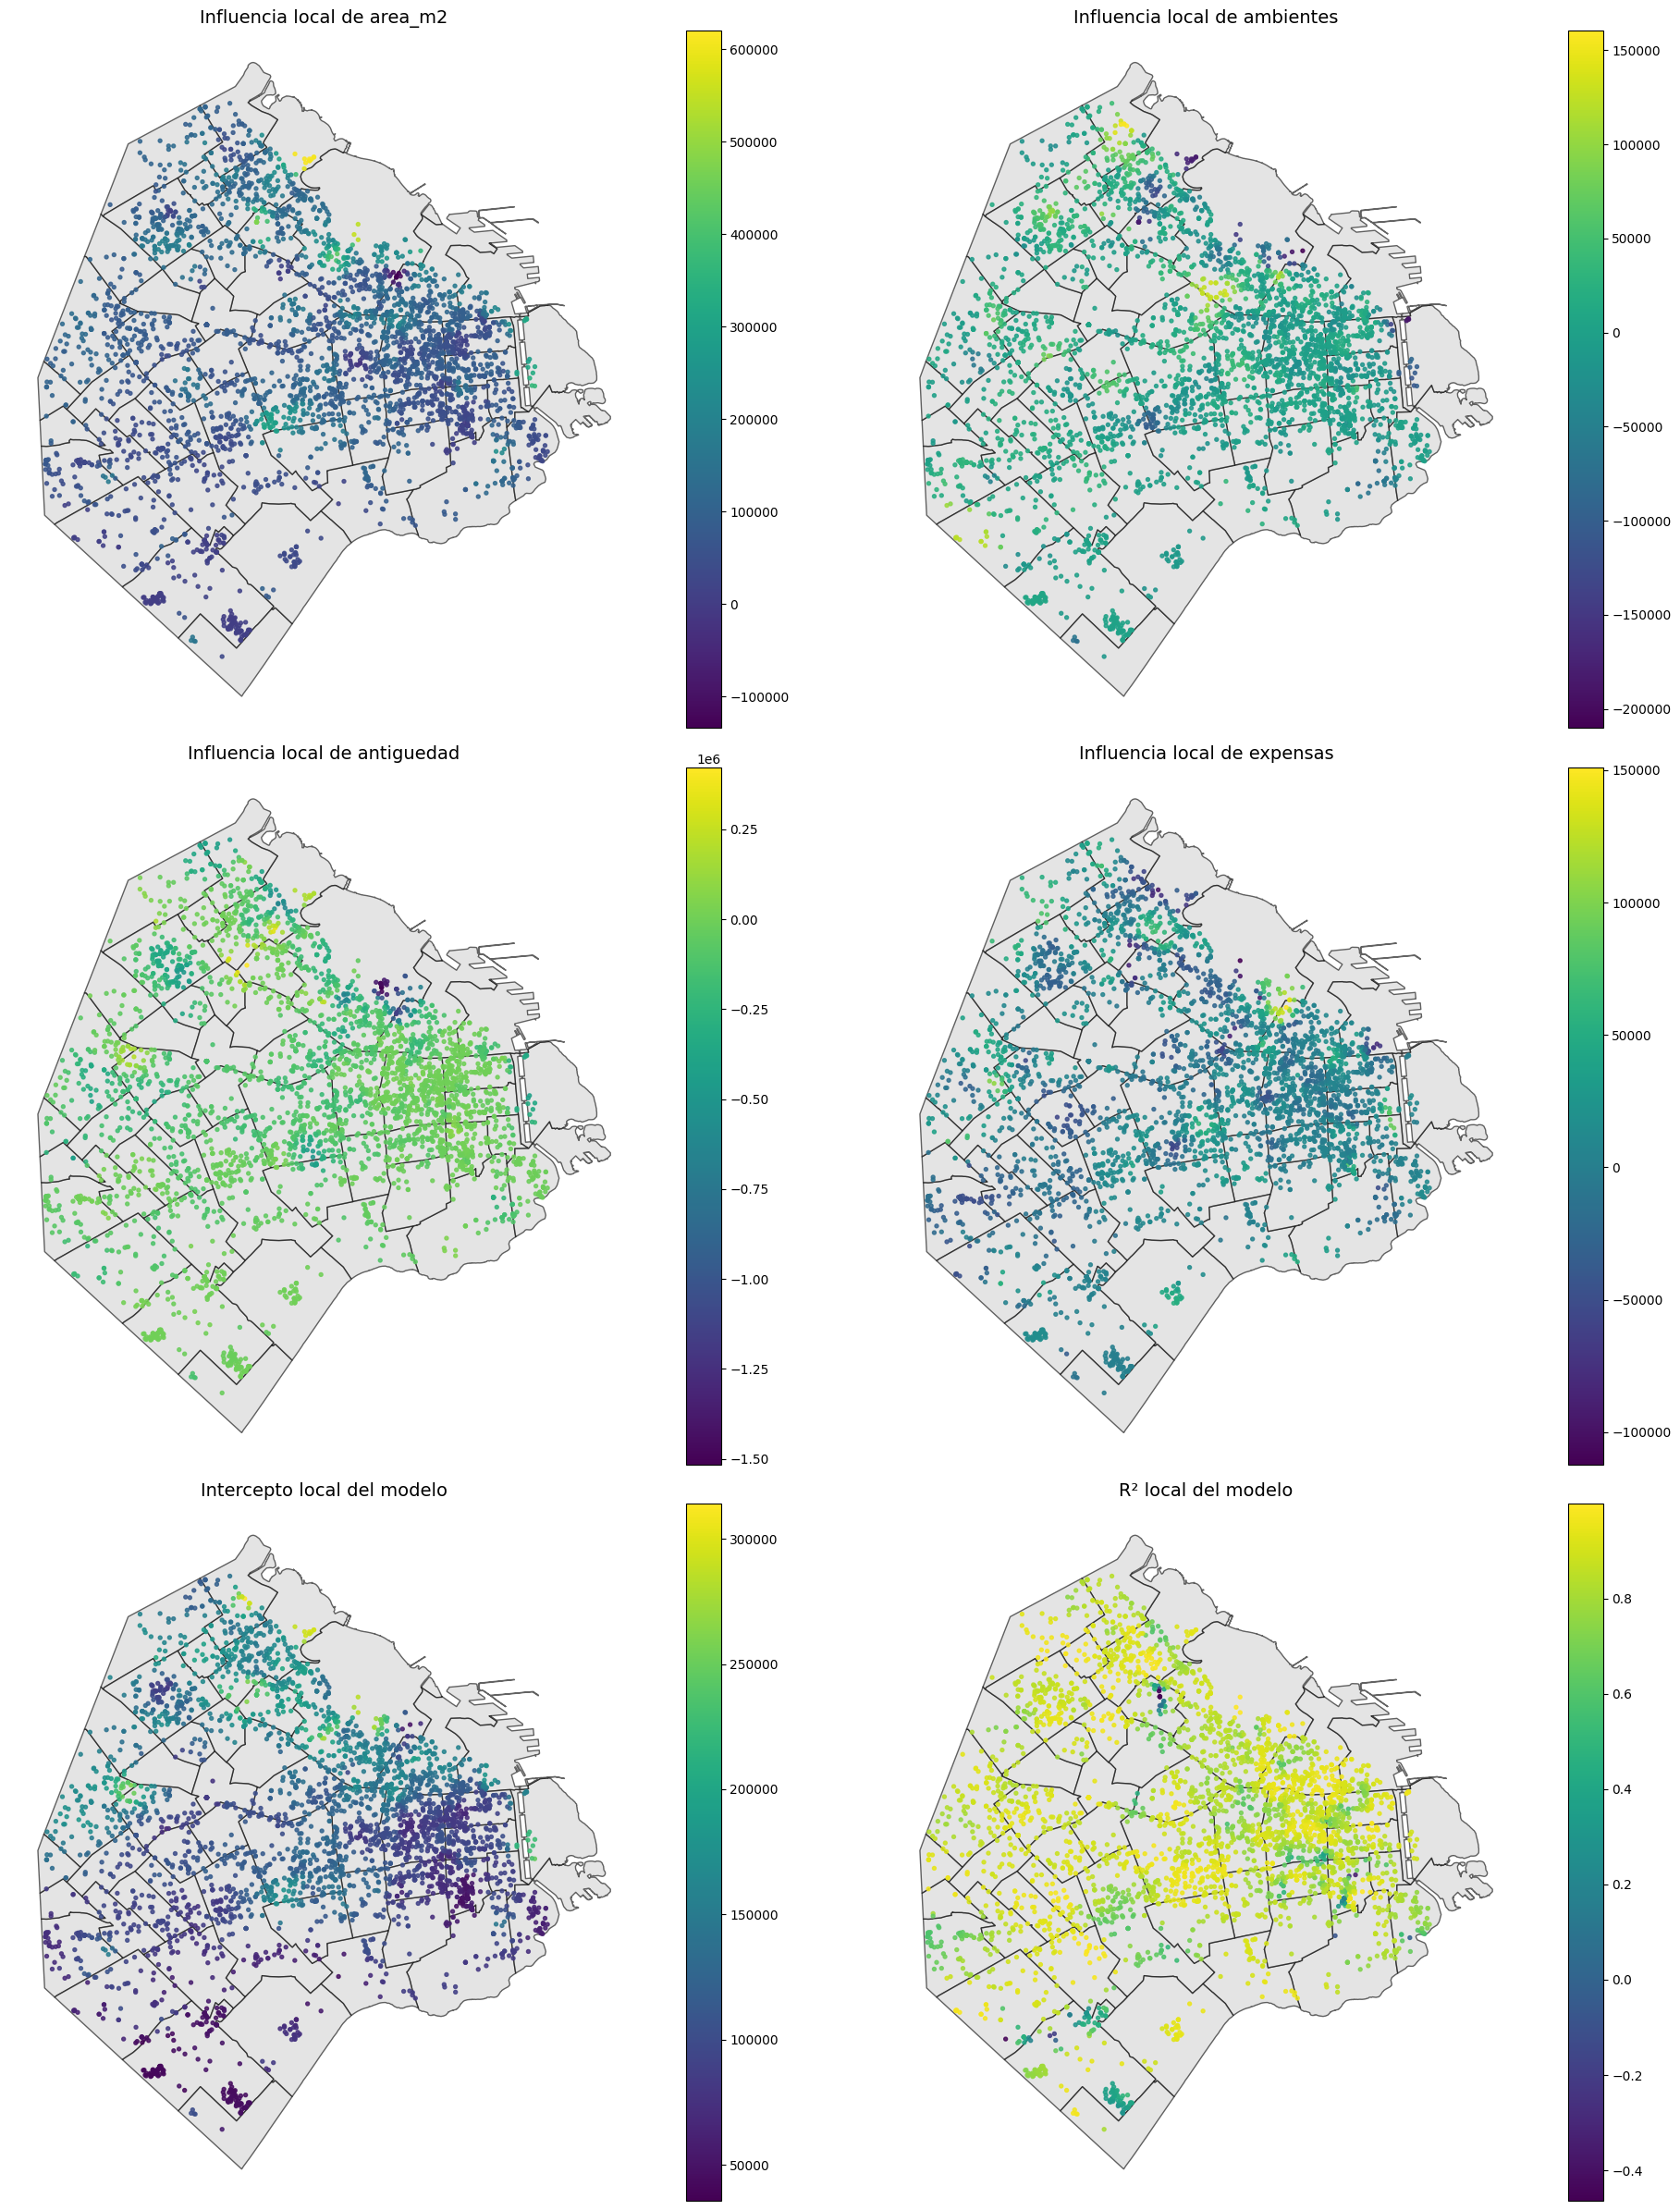

In [249]:
coef_names = [
    "beta_area_m2", "beta_ambientes","beta_antiguedad", 
    "beta_expensas", "intercept", "local_R2"
]

fig, axes = plt.subplots(3, 2, figsize=(20, 24))
axes = axes.flatten()

barrios = barrios.to_crs(epsg=3857)
gdf_train = gdf_train.to_crs(epsg=3857)

for ax, coef in zip(axes, coef_names):

    # ---- fondo: barrios ----
    barrios.plot(
        ax=ax,
        edgecolor="black",
        facecolor="lightgrey",
        alpha=0.6
    )

    # ---- puntos: resultados GWR ----
    gdf_train.plot(
        ax=ax,
        column=coef,
        legend=True,
        markersize=8,
        alpha=0.85
    )

    # ---- títulos más claros ----
    if coef.startswith("beta_"):
        title = f"Influencia local de {coef.replace('beta_', '')}"
    elif coef == "intercept":
        title = "Intercepto local del modelo"
    elif coef == "local_R2":
        title = "R² local del modelo"

    ax.set_title(title, fontsize=14)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [250]:
tvals = pd.DataFrame(
    res.tvalues[:, 1:],
    columns=var_names,
    index=gdf_train.index
)
tvals = pd.DataFrame(
    res.tvalues[:, 1:],
    columns=var_names,
    index=gdf_train.index
)
significant = np.abs(tvals) > 1.96
significant

(significant).mean() * 100


area_m2      70.472955317
ambientes    16.853932584
antiguedad   23.647765874
expensas     18.474000523
dtype: float64

Kriging en residuos. No aporta casi nada asique conviene no tenerlo en cuenta para reducir la complejidad del modelo.

In [251]:
gdf_train = gdf_train.to_crs(epsg=3857)
gdf_test = gdf_test.to_crs(epsg=3857)

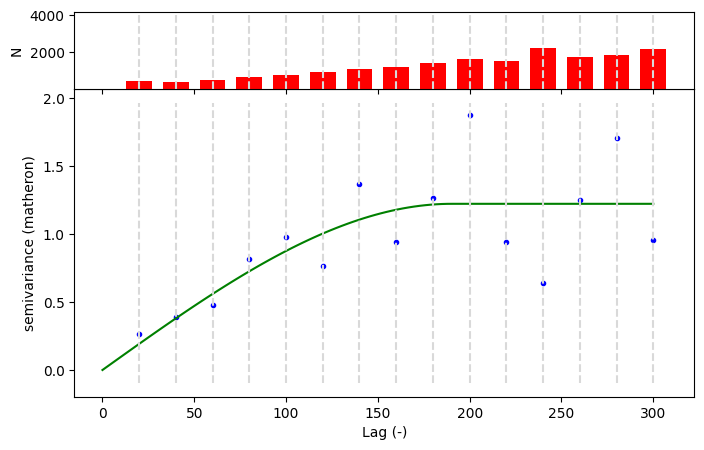

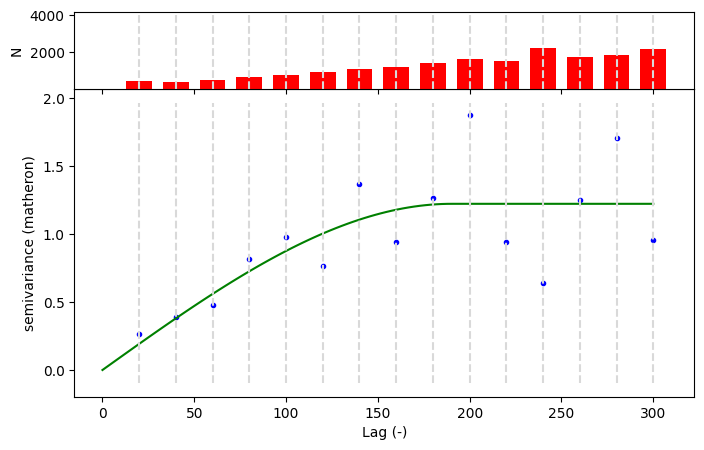

In [252]:

coords = np.column_stack([
    gdf_train.geometry.x,
    gdf_train.geometry.y
])

y_train_true = gdf_train['precio'].values
y_train_pred = model.predict(
        gdf_train,
        features_vars=[
            'area_m2',
            'ambientes',
            'antiguedad',
            'expensas'
        ],
        response_var='precio'
)
residuals = y_train_true - y_train_pred

V = Variogram(
    coords,
    residuals,
    model='spherical',   # o 'exponential', 'gaussian'
    n_lags=15,
    maxlag=300,     # o una distancia en metros
    normalize=False
)
V.plot()

In [253]:
coords = np.column_stack([
    gdf_train.geometry.x,
    gdf_train.geometry.y
])
coords_test = np.column_stack([
    gdf_test.geometry.x,
    gdf_test.geometry.y
])
sill, range_, _ = V.parameters
nugget = 0.0002  
OK = UniversalKriging(
    coords[:,0],
    coords[:,1],
    gdf_train['precio'].values,
    variogram_model='gaussian',
    variogram_parameters=[sill, range_, nugget]
)
z_pred, ss = OK.execute('points', coords_test[:,0], coords_test[:,1])

KeyboardInterrupt: 

In [ ]:
y_test_pred_model_y_residual_kriging = y_test_pred + z_pred

rmse = np.sqrt(mean_squared_error(
    gdf_test['precio'].values,
    y_test_pred_model_y_residual_kriging
))

mae = mean_absolute_error(
    gdf_test['precio'].values,
    y_test_pred_model_y_residual_kriging
)

rmse, mae


(467775.64209391776, 164807.26325179724)

In [ ]:
print("z_pred stats:")
print("min:", z_pred.min())
print("max:", z_pred.max())
print("mean:", z_pred.mean())
print("std:", z_pred.std())

z_pred stats:
min: -4040826.119092974
max: 8127287.1154322615
mean: 103030.84664663285
std: 499857.61512590386


In [ ]:

rmse = np.sqrt(mean_squared_error(
    y_test_true,
    y_test_pred_model_y_residual_kriging
))

mae = mean_absolute_error(
    y_test_true,
    y_test_pred_model_y_residual_kriging
)

rmse, mae

(467775.64209391776, 164807.26325179724)

In [ ]:
(y_test_pred_model_y_residual_kriging <= 0).sum()
y_test_pred_model_y_residual_kriging.min(), y_test_pred_model_y_residual_kriging.max()
y_test_pred_model_y_residual_kriging.min(), y_test_pred_model_y_residual_kriging.max()

(-3986206.834764079, 8343045.664306913)

Local outlier detection con Lisa

In [ ]:
from esda.moran import Moran_Local
from libpysal.weights import KNN


coords = np.column_stack([
    gdf.geometry.x,
    gdf.geometry.y
])


w = KNN.from_array(coords, k=15)
w.transform = "r"

y_true = gdf['precio'].values

model_global = SpatialKernelPriceModel(gdf)

model_global.fit(
    data=gdf,
    features_vars=[
        'area_m2',
        'ambientes',
        'antiguedad',
        'expensas'
    ],
    response_var='precio'
)

y_pred = model_global.predict(
    gdf,
    features_vars=[
        'area_m2',
        'ambientes',
        'antiguedad',
        'expensas'
    ],
    response_var='precio'
)
residuals = y_true - y_pred
lisa = Moran_Local(residuals, w)


In [ ]:
outliers = (
    (lisa.q == 3)    # Low-High
& (lisa.p_sim < 0.05))
gdf[outliers]
gdf[outliers].to_csv("outliers_lisa_regressionKriginModel.csv", index=False)


In [ ]:
gdf_ml = gdf.copy()

gdf_ml['lon'] = gdf_ml.geometry.x
gdf_ml['lat'] = gdf_ml.geometry.y



In [ ]:
gdf_ml.columns

Index(['id', 'url', 'precio', 'expensas', 'area_m2', 'dormitorios',
       'antiguedad', 'puntaje_arg_prop', 'imagen_path', 'image_url', 'lat',
       'lon', 'valido_desde', 'valido_hasta', 'geometry', 'index_right',
       'barrio', 'comuna', 'ambientes', 'precio_m2',
       'superficie_por_ambientes', 'tipo_inmueble_departamento',
       'tipo_inmueble_ph'],
      dtype='object')

In [ ]:
features = [
    'lat', 'lon',
    'area_m2',
    'ambientes',
    'antiguedad',
    'expensas'
]

target = 'precio'

df = gdf_ml[features + [target]].copy()

# eliminar filas con target faltante
df = df.dropna(subset=[target])


In [ ]:
from sklearn.impute import SimpleImputer

X = df[features]
y = df[target]

imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X)


In [ ]:
from sklearn.model_selection import train_test_split
coords = np.column_stack([
    gdf_ml.geometry.x.values,
    gdf_ml.geometry.y.values
])


X_train, X_test, y_train, y_test, coords_train, coords_test = train_test_split(
    X, y, coords, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

kr_rf = RegressionKriging(
    rf,
    n_closest_points=15,
)

kr_rf.fit(X_train, coords_train, y_train)
rf.fit(X_train, y_train)


Finished learning regression model
Finished kriging residuals


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred_kr_rf = kr_rf.predict(X_test, coords_test)
y_pred_rf = rf.predict(X_test)
print("RF R2:", r2_score(y_test, y_pred_rf))
print("RF MAE:", mean_absolute_error(y_test, y_pred_rf))
print("KR-RF R2:", r2_score(y_test, y_pred_kr_rf))
print("KR-RF MAE:", mean_absolute_error(y_test, y_pred_kr_rf))

RF R2: 0.7360639322546298
RF MAE: 29179.498712479595
KR-RF R2: 0.7427011099156868
KR-RF MAE: 27991.26166690664


In [ ]:
import pandas as pd

pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)


area_m2       0.366073
expensas      0.201278
ambientes     0.167736
lat           0.142169
lon           0.061774
antiguedad    0.060970
dtype: float64

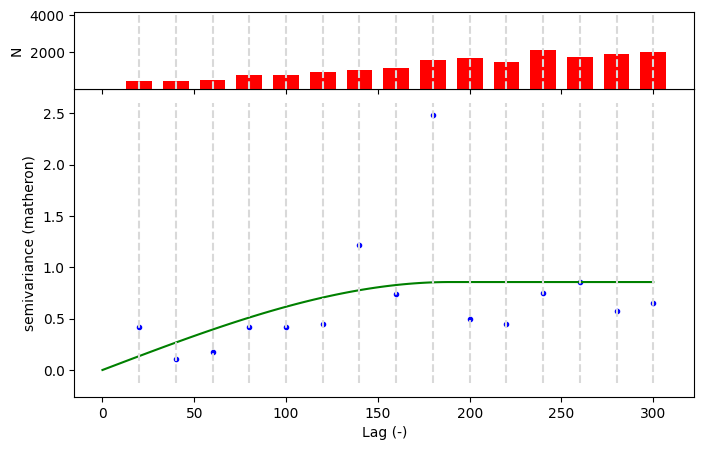

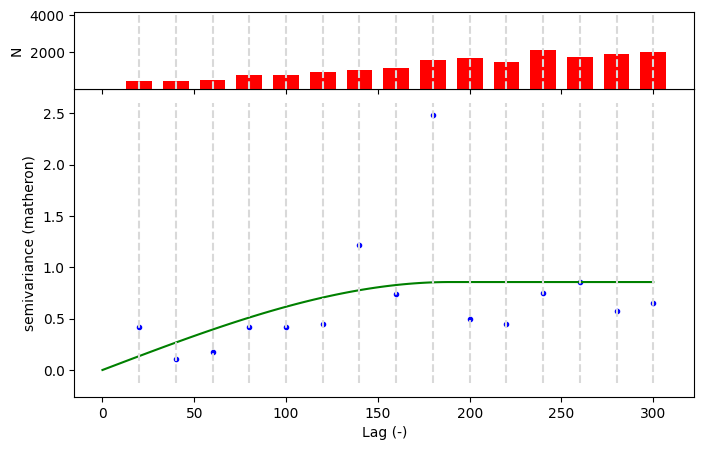

In [ ]:


y_pred_rf_train = kr_rf.predict(X_train, coords_train)

residuals = y_train - y_pred_rf_train 

V = Variogram(
    coords_train,
    residuals,
    model='spherical',   # o 'exponential', 'gaussian'
    n_lags=15,
    maxlag=300,     # o una distancia en metros
    normalize=False
)
V.plot()

In [ ]:
from esda.moran import Moran_Local
from libpysal.weights import KNN

gdf_ml.to_crs(epsg=3857)

coords = np.column_stack([
    gdf_ml.geometry.x,
    gdf_ml.geometry.y
])


w = KNN.from_array(coords, k=15)
w.transform = "r"


y_pred = rf.predict(
    X_imp
)

residuals = y - y_pred
lisa = Moran_Local(residuals, w)

In [ ]:
outliers = (
    (lisa.q == 3)    # Low-High
& (lisa.p_sim < 0.05))
gdf_ml[outliers]
gdf_ml[outliers].drop(columns="geometry").to_csv(
    "outliers.csv",
    index=False
)
